In [1]:
from pathlib import Path
import sys 
import tqdm 

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
from torchvision import transforms
from torch.utils.data import DataLoader

from src.datasets.eurosat_dataset import EuroSATDataset

In [4]:
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

OUTPUT_DIR = PROJECT_ROOT / "outputs" 
CONFUSION_DIR = OUTPUT_DIR / "confusion_matrices"
FIGURE_DIR = OUTPUT_DIR / "figures"

train_csv = PROCESSED_DIR / "train_spatial.csv"
val_csv = PROCESSED_DIR / "val_spatial.csv"
test_csv = PROCESSED_DIR / "test_spatial.csv"

In [5]:
EUROSAT_MEAN = (
    0.34437724,
    0.38029198,
    0.40777111
)

EUROSAT_STD = (
    0.20265734,
    0.13689059,
    0.11554374
)

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD)
])

In [7]:
train_dataset = EuroSATDataset(
    train_csv,
    transform=train_transform
)

val_dataset = EuroSATDataset(
    val_csv,
    transform=eval_transform
)

test_dataset = EuroSATDataset(
    test_csv,
    transform=eval_transform
)

In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [9]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [10]:
resnet18 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

In [11]:
for param in resnet18.parameters():
    param.requires_grad = False

In [12]:
resnet18.fc = nn.Linear(
    resnet18.fc.in_features,
    10
)

In [13]:
resnet18 = resnet18.to(DEVICE)

In [14]:
total_params = sum(
    p.numel()
    for p in resnet18.parameters()
)

trainable_params = sum(
    p.numel()
    for p in resnet18.parameters()
    if p.requires_grad
)

print(total_params)
print(trainable_params)

11181642
5130


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet18.fc.parameters(),
    lr=1e-3
)

In [16]:
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0.0
    ):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float("inf")
        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

In [17]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm.tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss
        / len(loader)
    )

    epoch_acc = (
        correct
        / total
    )

    return epoch_loss, epoch_acc

In [18]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss
        / len(loader)
    )

    epoch_acc = (
        correct
        / total
    )

    return epoch_loss, epoch_acc

In [19]:
EPOCHS = 20
PATIENCE = 5

early_stopping = EarlyStopping(
    patience=PATIENCE
)

best_val_loss = float("inf")

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        resnet18,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        resnet18,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")
    print("-" * 50)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            resnet18.state_dict(),
            CHECKPOINT_DIR / "resnet18_frozen_best.pt"
        )

        print(
            f"Saved new best model (Val Loss = {val_loss:.4f})"
        )

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print(
            f"Early stopping triggered at epoch {epoch+1}"
        )

        break

print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)

100%|██████████| 337/337 [00:18<00:00, 18.56it/s]


Epoch [1/20]
Train Loss: 0.7716
Train Acc : 0.7833
Val Loss  : 1.0513
Val Acc   : 0.6680
--------------------------------------------------
Saved new best model (Val Loss = 1.0513)


100%|██████████| 337/337 [00:17<00:00, 19.02it/s]


Epoch [2/20]
Train Loss: 0.3844
Train Acc : 0.8865
Val Loss  : 0.9698
Val Acc   : 0.6911
--------------------------------------------------
Saved new best model (Val Loss = 0.9698)


100%|██████████| 337/337 [00:17<00:00, 19.07it/s]


...

Epoch [11/20]
Train Loss: 0.2442
Train Acc : 0.9182
Val Loss  : 0.8498
Val Acc   : 0.7408
--------------------------------------------------


100%|██████████| 337/337 [00:18<00:00, 18.34it/s]


Epoch [12/20]
Train Loss: 0.2389
Train Acc : 0.9185
Val Loss  : 0.9552
Val Acc   : 0.7224
--------------------------------------------------


100%|██████████| 337/337 [00:18<00:00, 17.80it/s]


Epoch [13/20]
Train Loss: 0.2346
Train Acc : 0.9204
Val Loss  : 0.7866
Val Acc   : 0.7541
--------------------------------------------------
Early stopping triggered at epoch 13
Best Validation Loss: 0.6924


In [20]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = resnet18(images)

print(outputs.shape)

torch.Size([64, 10])


In [21]:
resnet18.load_state_dict(
    torch.load(
        CHECKPOINT_DIR / "resnet18_frozen_best.pt",
        map_location=DEVICE
    )
)

resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = resnet18(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_preds = np.array(all_preds)

all_labels = np.array(all_labels)

print(len(all_preds))
print(len(all_labels))

2658
2658


In [23]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

Test Accuracy: 0.7506
Macro F1: 0.7638


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt

In [25]:
label_map = {
    0:"AnnualCrop",
    1:"Forest",
    2:"HerbaceousVegetation",
    3:"Highway",
    4:"Industrial",
    5:"Pasture",
    6:"PermanentCrop",
    7:"Residential",
    8:"River",
    9:"SeaLake"
}

In [26]:
class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [27]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
AnnualCrop,0.901345,0.730909,0.807229,275.000000
Forest,0.860870,0.942857,0.900000,105.000000
HerbaceousVegetation,0.853704,0.652051,0.739374,707.000000
Highway,0.885350,0.696742,0.779804,399.000000
Industrial,0.715152,0.967213,0.822300,244.000000
Pasture,0.422222,0.863636,0.567164,22.000000
PermanentCrop,0.519939,0.729032,0.606983,465.000000
Residential,0.815217,0.910931,0.860421,247.000000
River,0.744898,0.682243,0.712195,107.000000
SeaLake,0.984615,0.735632,0.842105,87.000000


In [28]:
report_path = (
    FIGURE_DIR
    / "resnet18_frozen_classification_report.csv"
)

report_df.to_csv(
    report_path
)

print(report_path)

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\figures\resnet18_frozen_classification_report.csv


In [29]:
per_class_f1 = report_df[
    ["f1-score"]
].iloc[:10]

per_class_f1

,f1-score
AnnualCrop,0.807229
Forest,0.900000
HerbaceousVegetation,0.739374
Highway,0.779804
Industrial,0.822300
Pasture,0.567164
PermanentCrop,0.606983
Residential,0.860421
River,0.712195
SeaLake,0.842105


In [30]:
f1_path = (
    FIGURE_DIR
    / "resnet18_frozen_per_class_f1.csv"
)

per_class_f1.to_csv(
    f1_path
)

print(f1_path)

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\figures\resnet18_frozen_per_class_f1.csv


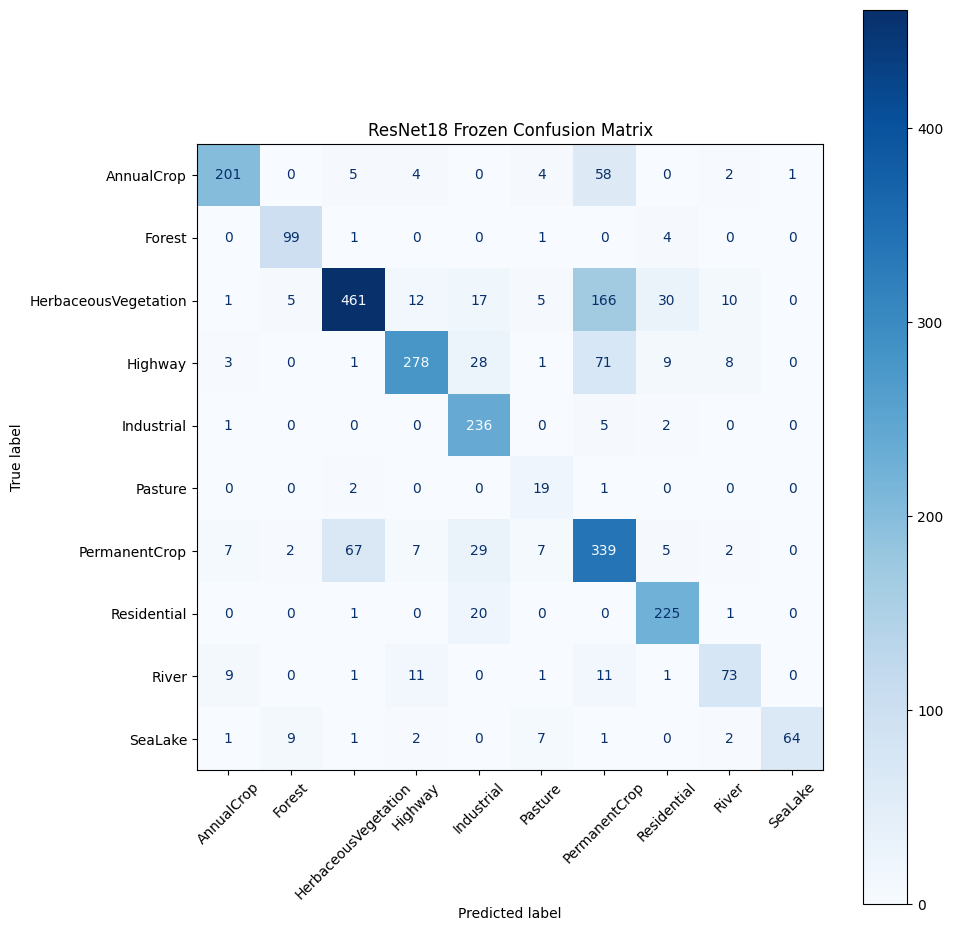

In [31]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "ResNet18 Frozen Confusion Matrix"
)

plt.tight_layout()

In [32]:
cm_path = (
    CONFUSION_DIR
    / "resnet18_frozen_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(cm_path)

<Figure size 640x480 with 0 Axes>

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\confusion_matrices\resnet18_frozen_confusion_matrix.png


In [33]:
summary = pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "Macro_F1"
        ],
        "Value":[
            accuracy,
            macro_f1
        ]
    }
)

summary_path = (
    FIGURE_DIR
    / "resnet18_frozen_metrics.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

summary

,Metric,Value
0,Accuracy,0.750564
1,Macro_F1,0.763757
